In [ ]:
#Assignment No 01_Part B

In [ ]:
#Step 1
#import libraries
import pandas as pd
import numpy as np

In [2]:
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [3]:
# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [5]:
# TensorFlow / Keras Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
# Load Dataset
# Read the CSV file
df=pd.read_csv("D:\Advanced DS\Breast_Cancer Dataset.csv")

# Display first five rows
df.head()

<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
C:\Users\HP\AppData\Local\Temp\ipykernel_11836\2452487104.py:3: SyntaxWarning: invalid escape sequence '\A'
  df=pd.read_csv("D:\Advanced DS\Breast_Cancer Dataset.csv")


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [10]:
# Display dataset information

print("Shape of Dataset :", df.shape)


print("\nColumn Names\n")
print(df.columns)

print("\nDataset Information\n")
print(df.info())

print("\nStatistical Summary\n")
print(df.describe())

print("\nMissing Values\n")
print(df.isnull().sum())

Shape of Dataset : (569, 33)

Column Names

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1

In [12]:
# Check Target Column
# Display unique values of target column

print("Unique Diagnosis Values:")
print(df["diagnosis"].unique())

print("\nDiagnosis Value Counts:")
print(df["diagnosis"].value_counts())

Unique Diagnosis Values:
['M' 'B']

Diagnosis Value Counts:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [13]:
# Handle Missing Values
# Identify numerical and categorical columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical missing values using median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values using mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values After Cleaning\n")
print(df.isnull().sum())

Missing Values After Cleaning

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [14]:
# Encode Target Variable
encoder = LabelEncoder()

df["diagnosis"] = encoder.fit_transform(df["diagnosis"])

# Display encoded values
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [15]:
# Remove unnecessary columns if they exist

columns_to_drop = []

if "id" in df.columns:
    columns_to_drop.append("id")

if "Unnamed: 32" in df.columns:
    columns_to_drop.append("Unnamed: 32")

df.drop(columns=columns_to_drop, inplace=True)

print("Remaining Columns:")
print(df.columns)

Remaining Columns:
Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [16]:
# Target Column
target = "diagnosis"

# Independent Variables
X = df.drop(target, axis=1)

# Dependent Variable
y = df[target]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (569, 30)
Target Shape : (569,)


In [17]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (455, 30)
Testing Samples : (114, 30)


In [18]:
# Standardize the features

scaler = StandardScaler()

# Fit the scaler only on training data
X_train = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test = scaler.transform(X_test)

print("Feature Standardization Completed")
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Feature Standardization Completed
Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


In [19]:
# Build Artificial Neural Network for Classification

model = Sequential()

# Input Layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden Layer 1
model.add(Dense(
    units=64,
    activation='relu'
))

# Hidden Layer 2
model.add(Dense(
    units=32,
    activation='relu'
))

# Hidden Layer 3
model.add(Dense(
    units=16,
    activation='relu'
))

# Output Layer
# Sigmoid is used for binary classification
model.add(Dense(
    units=1,
    activation='sigmoid'
))

print("ANN Classification Model Created")

ANN Classification Model Created


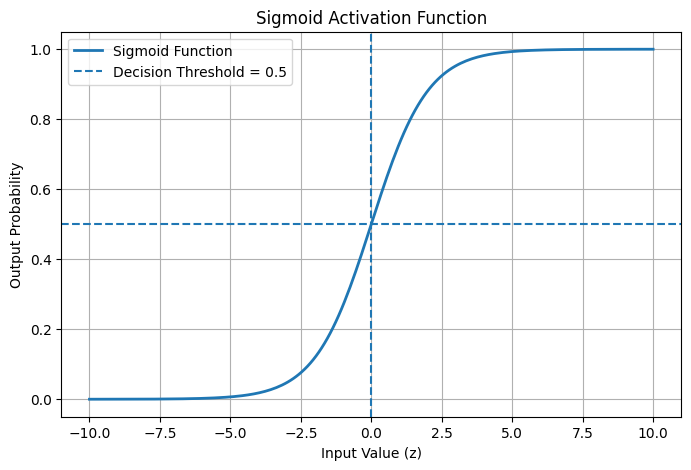

In [20]:
# Sigmoid Function Visualization

import numpy as np
import matplotlib.pyplot as plt

# Define Sigmoid Function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Generate input values
x = np.linspace(-10, 10, 200)

# Calculate sigmoid output
y = sigmoid(x)

# Create the graph
plt.figure(figsize=(8, 5))

plt.plot(
    x,
    y,
    linewidth=2,
    label='Sigmoid Function'
)

# Decision threshold
plt.axhline(
    y=0.5,
    linestyle='--',
    label='Decision Threshold = 0.5'
)

# Center point
plt.axvline(
    x=0,
    linestyle='--'
)

# Labels
plt.xlabel("Input Value (z)")
plt.ylabel("Output Probability")

plt.title("Sigmoid Activation Function")

plt.grid(True)
plt.legend()

plt.show()

In [21]:
# Display ANN Model Architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Compile the ANN Model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compilation Completed")

Model Compilation Completed


In [23]:
# Early Stopping to reduce overfitting

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the ANN Model

history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.6923 - loss: 0.5551 - val_accuracy: 0.8681 - val_loss: 0.3650
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9286 - loss: 0.3042 - val_accuracy: 0.9231 - val_loss: 0.2429
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9670 - loss: 0.1833 - val_accuracy: 0.9560 - val_loss: 0.1714
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9835 - loss: 0.1131 - val_accuracy: 0.9670 - val_loss: 0.1322
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9835 - loss: 0.0806 - val_accuracy: 0.9560 - val_loss: 0.1171
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9890 - loss: 0.0641 - val_accuracy: 0.9560 - val_loss: 0.1106
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9863 - loss: 0.0550 - val_accuracy: 0.9560 - val_loss: 0.1071
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9945 - loss: 0.0481 - val_accuracy: 0.9560 

In [24]:
# Evaluate the model on test data

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss     :", loss)
print("Test Accuracy :", accuracy)

Test Loss     : 0.07095950841903687
Test Accuracy : 0.9824561476707458


In [25]:
# Predict probability values

y_pred_probability = model.predict(X_test)

# Convert probability into class labels

y_pred = (
    y_pred_probability >= 0.5
).astype(int).flatten()

print("First 10 Predicted Probabilities:")
print(y_pred_probability[:10])

print("\nFirst 10 Predicted Classes:")
print(y_pred[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
First 10 Predicted Probabilities:
[[5.1447900e-05]
 [9.9998719e-01]
 [3.1454813e-02]
 [5.4689211e-01]
 [1.9526756e-01]
 [3.1769171e-04]
 [9.1769910e-01]
 [4.2248730e-04]
 [8.9767476e-05]
 [4.2861723e-03]]

First 10 Predicted Classes:
[0 1 0 1 0 0 1 0 0 0]


In [26]:
# Calculate Classification Metrics

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1 Score  :", round(f1, 4))

Accuracy  : 0.9825
Precision : 1.0
Recall    : 0.9524
F1 Score  : 0.9756


In [27]:
# Display Classification Report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

           B       0.97      1.00      0.99        72
           M       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [28]:
# Calculate Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[72  0]
 [ 2 40]]


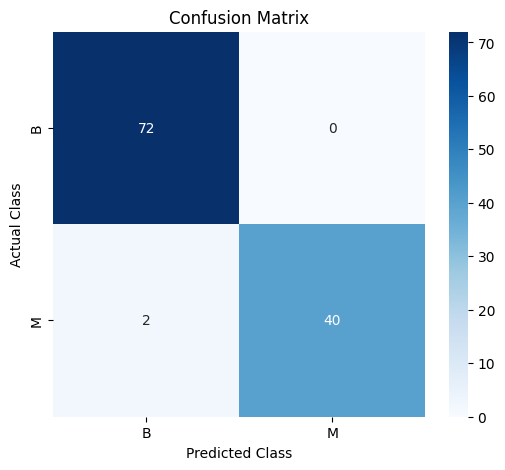

In [29]:
# Visualize Confusion Matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title("Confusion Matrix")

plt.show()

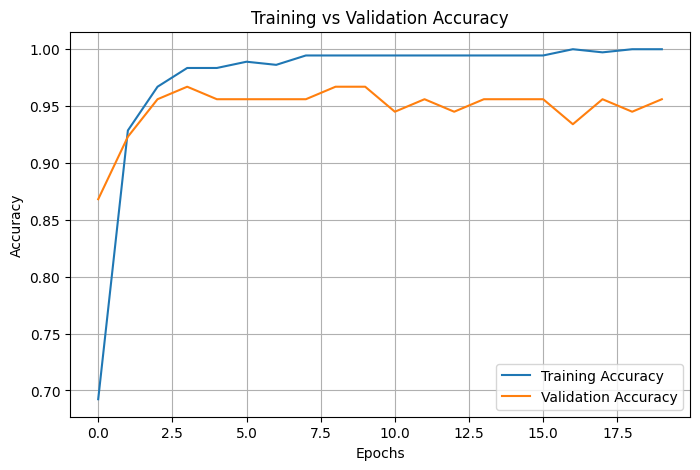

In [30]:
# Plot Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [31]:
# Final Model Performance Summary

performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

performance

,Metric,Score
0,Accuracy,0.982456
1,Precision,1.000000
2,Recall,0.952381
3,F1 Score,0.975610
